# 06 — Cohort Retention & Lifecycle Analysis

*25 monthly acquisition cohorts · 7,877 customers · M+1 retention 15.2% · 12M LTV $524.58/customer*

## Executive Summary

Groups 7,877 customers into **25 monthly acquisition cohorts** (Sept 2023 – Sept 2025), constructs a full retention matrix, and decomposes the lifecycle into customer-count retention, revenue retention, AOV stability, and cumulative LTV accumulation. Segment stratification cross-references NB01 loyalty tiers and NB03 cluster labels to link acquisition timing with long-run customer quality.

**Headline finding: 84.8% M+1 dropout — structural, not episodic.** Kruskal-Wallis across all 25 cohorts returns p = 0.46 — acquisition quality is consistent. The problem is universal, not tied to any channel, period, or category. Revenue churn tracks customer churn within ±0.9%, ruling out a high-value customer flight problem. The fix is onboarding, not segmentation.

| Output | Dimensions | Purpose |
|---|---|---|
| `cohort_retention.parquet` | 24 cohorts × 24 periods | Full retention rate matrix |
| `cohort_ltv.parquet` | 24 cohorts × 24 periods | Cumulative LTV per acquired customer |
| `cohort_summary.parquet` | 24 cohorts × 9 metrics | Per-cohort KPI roll-up |
| `cohort_segment_ltv.parquet` | 4 segments × 3 windows | LTV by loyalty tier at 3M / 6M / 12M |

**Upstream dependencies:** `enhanced_df.parquet` and `rfm_df.parquet` (NB01) · `customer_segments.csv` (NB03)

**Key assumptions:** Cohort = first calendar month of earliest non-returned order · Retention = ≥1 non-returned order in the measurement period · Incomplete months (≥ `time_series.incomplete_month_cutoff` in config) excluded from all rate denominators to prevent survivorship bias · Cohorts < 30 customers flagged low-n and excluded from statistical tests

## 1. Environment Setup

`random_state = 42` seeded globally. Structured logging scoped to run ID. All business thresholds — retention benchmarks, minimum cohort size, dropout critical threshold, LTV windows — externalised to `config.yaml → notebook6` · nothing hardcoded downstream.

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import random
from pathlib import Path

# Statistical testing
from scipy.stats import spearmanr

# ── Project path setup ──────────────────────────────────────────────────────
current_dir = Path.cwd()
if (current_dir.parent / 'src').exists():
    sys.path.insert(0, str(current_dir.parent / 'src'))
elif (current_dir / 'src').exists():
    sys.path.insert(0, str(current_dir / 'src'))
else:
    raise RuntimeError("Cannot find src directory. Run from notebooks/ or project root.")

# Custom utilities
from n6_utils import (
    get_project_root, load_config, setup_logger,
    verify_project_structure, set_run_id, generate_run_id
)

# ── Run ID & project root ────────────────────────────────────────────────────
RUN_ID = generate_run_id()
set_run_id(RUN_ID)
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# ── Logging ──────────────────────────────────────────────────────────────────
logger = setup_logger(__name__)
logger.info("=" * 60)
logger.info("NOTEBOOK 06: Cohort Retention & Lifecycle Analysis")
logger.info("=" * 60)
logger.info(f"Project root: {PROJECT_ROOT}")
logger.info(f"Run ID: {RUN_ID}")

verify_project_structure(PROJECT_ROOT)
logger.info("Project structure verified")

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Configuration ────────────────────────────────────────────────────────────
config       = load_config(PROJECT_ROOT / 'config.yaml')
nb6_cfg      = config.get('notebook6', {})
viz_cfg      = config.get('visualization', {})
ts_cfg       = config.get('time_series', {})
disp_cfg     = nb6_cfg.get('display', {})
rules        = nb6_cfg.get('business_rules', {})
stat_cfg     = nb6_cfg.get('statistical_tests', {})
ltv_cfg      = nb6_cfg.get('ltv', {})
scen_cfg     = nb6_cfg.get('scenarios', {})
nb03_cfg     = nb6_cfg.get('nb03_segments', {})
seg_clr_cfg  = nb6_cfg.get('segment_colors', {})
logger.info("Configuration loaded")

# ── Display options (driven by config) ───────────────────────────────────────
_float_fmt = disp_cfg.get('float_format', '{:,.4f}')
pd.set_option('display.float_format', lambda x: _float_fmt.format(x))
pd.set_option('display.max_columns', disp_cfg.get('max_columns'))   # None = show all
pd.set_option('display.max_rows',    disp_cfg.get('max_rows', 100))

# ── Visualization style — consistent with NB01-NB05 ─────────────────────────
plt.style.use(viz_cfg.get('style', 'seaborn-v0_8-whitegrid'))
COLORS    = viz_cfg.get('color_palette', ['#1B1F5E', '#1395F8', '#2E7D32', '#F57C00', '#C62828', '#757575'])
C_PRIMARY = viz_cfg.get('colors', {}).get('primary',   '#1B1F5E')
C_ACCENT  = viz_cfg.get('colors', {}).get('secondary', '#EA731D')
C_SUCCESS = viz_cfg.get('colors', {}).get('success',   '#2E7D32')
C_WARN    = viz_cfg.get('colors', {}).get('warning',   '#F57C00')
C_DANGER  = viz_cfg.get('colors', {}).get('danger',    '#C62828')
sns.set_palette(COLORS)

# ── Business rules (all from notebook6.business_rules) ───────────────────────
MIN_COHORT_SIZE       = rules.get('min_cohort_size',         30)
HEALTHY_M1_RETENTION  = rules.get('healthy_retention_month1', 0.25)
CRITICAL_DROPOUT_PCT  = rules.get('critical_dropout_pct',    0.70)
LTV_WINDOW_MONTHS     = rules.get('ltv_window_months',        12)

# ── Incomplete month cutoff (from global time_series block) ──────────────────
INCOMPLETE_CUTOFF = pd.Timestamp(ts_cfg.get('incomplete_month_cutoff', '2025-09-01'))

# ── Random seed (from notebook6) ─────────────────────────────────────────────
RANDOM_SEED = nb6_cfg.get('random_state', 42)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
logger.info(f"Random seed set to: {RANDOM_SEED}")
logger.info("=" * 60)

print(f"\nSetup complete!")
print(f"Run ID:               {RUN_ID}")
print(f"Random seed:          {RANDOM_SEED}")
print(f"Incomplete cutoff:    {INCOMPLETE_CUTOFF.date()}")
print(f"Min cohort size:      {MIN_COHORT_SIZE} customers")
print(f"Healthy M+1 target:   {HEALTHY_M1_RETENTION:.0%}")
print(f"LTV window:           {LTV_WINDOW_MONTHS} months")
print(f"Config loaded from:   {PROJECT_ROOT / 'config.yaml'}")


00:40:51 | INFO     | __main__ | ============================================================
00:40:51 | INFO     | __main__ | NOTEBOOK 06: Cohort Retention & Lifecycle Analysis
00:40:51 | INFO     | __main__ | ============================================================
00:40:51 | INFO     | __main__ | Project root: C:\Users\Rich Justine Gambe\Documents\AAA Projects\ecommerce-analytics-project
00:40:51 | INFO     | __main__ | Run ID: NB06-20260227-004051-CB6E
00:40:51 | INFO     | __main__ | Project structure verified
00:40:51 | INFO     | __main__ | Configuration loaded
00:40:51 | INFO     | __main__ | Random seed set to: 42
00:40:51 | INFO     | __main__ | ============================================================

Setup complete!
Run ID:               NB06-20260227-004051-CB6E
Random seed:          42
Incomplete cutoff:    2025-09-01
Min cohort size:      30 customers
Healthy M+1 target:   25%
LTV window:           12 months
Config loaded from:   C:\Users\Rich Justine Gambe\Docum

## 2. Data Loading & Integrity Validation

Loads `enhanced_df.parquet` (34,500 transactions) and `rfm_df.parquet` (7,903 customers) from NB01. Seven integrity checks run before a single cohort is constructed — customer count tolerance, RFM subset validation, future-date check, `returned` flag binarisation, date range bounds, null customer IDs, and non-negative `total_amount` on completed orders. **Pipeline halts on any FAIL** — retention rates are only trustworthy when the inputs are clean.

In [2]:
from n6a_data_loader import load_cohort_inputs, validate_cohort_integrity

# Load both datasets
df_tx, rfm_df = load_cohort_inputs(config=config, run_id=RUN_ID, verbose=True)

# Cross-dataset integrity validation
integrity = validate_cohort_integrity(df_tx, rfm_df, config, run_id=RUN_ID)

print(f"\n{'='*80}")
print("DATA INTEGRITY VALIDATION".center(80))
print("=" * 80)

for check in integrity['checks']:
    symbol = 'PASS' if check['status'] == 'PASS' else ('WARN' if check['status'] == 'WARN' else 'FAIL')
    print(f"  [{symbol}] {check['name']:<50} {check['detail']}")

print()
print(f"  Passed: {integrity['passed']} | Warnings: {integrity['warnings']} | Failed: {integrity['failed']}")

if not integrity['all_passed']:
    raise ValueError("Data integrity validation failed — review issues above before proceeding")

print(f"\nDATA GATE: PASSED — proceeding to cohort construction")

print(f"\n{'='*80}")
print("INPUT SUMMARY".center(80))
print("=" * 80)
print(f"  Transactions:     {len(df_tx):,} rows x {df_tx.shape[1]} columns")
print(f"  Date range:       {df_tx['order_date'].min().date()} to {df_tx['order_date'].max().date()}")
print(f"  Unique customers: {df_tx['customer_id'].nunique():,}")
print(f"  RFM customers:    {len(rfm_df):,}")
print(f"  Returned orders:  {df_tx['returned'].sum():,} ({df_tx['returned'].mean()*100:.1f}%)")
print("=" * 80)


00:40:51 | INFO     | n6a_data_loader | [NB06-20260227-004051-CB6E] Loading transactions from enhanced_df.parquet
00:40:51 | INFO     | n6a_data_loader | [NB06-20260227-004051-CB6E] Transactions loaded: 34500 rows x 17 cols
00:40:51 | INFO     | n6a_data_loader | [NB06-20260227-004051-CB6E] Loading RFM data from rfm_df.parquet
00:40:51 | INFO     | n6a_data_loader | [NB06-20260227-004051-CB6E] RFM data loaded: 7903 rows x 17 cols

                               DATA LOAD SUMMARY                                
  Transactions:      34,500 rows  x  17 columns
  Date range:        2023-09-12 to 2025-09-11
  Unique customers:  7,903
  Returned orders:   1,903  (5.5%)
  RFM customers:     7,903  x  17 columns
00:40:51 | INFO     | n6a_data_loader | [NB06-20260227-004051-CB6E] PASS: Customer count within 2% of expected — Expected 7,903, actual 7,903, delta +0
00:40:51 | INFO     | n6a_data_loader | [NB06-20260227-004051-CB6E] PASS: RFM customers are subset of transaction customers — 0 RFM ID

## 3. Cohort Construction

Three-step pipeline: assign acquisition cohorts → build customer-month activity matrix → compute retention rates.

**Acquisition cohort:** calendar month of each customer's earliest non-returned order. **Period offset:** months elapsed since acquisition (M+0 = acquisition month). **Activity:** ≥1 non-returned order placed in that period. Periods at or after `incomplete_month_cutoff` are masked to NaN — partial months are excluded from all rate denominators to prevent survivorship distortion.

26 return-only customers (no successful orders) dropped before cohort assignment. 356 transactions with negative period offsets — orders recorded before the customer's first successful purchase — clamped to 0.

In [3]:
from n6b_cohort_builder import (
    assign_acquisition_cohorts,
    build_activity_matrix,
    compute_retention_rates,
    flag_low_n_cohorts
)

logger.info("Starting cohort construction")

# Step 1: Assign acquisition cohorts
df_cohorted = assign_acquisition_cohorts(
    df=df_tx,
    customer_id_col='customer_id',
    date_col='order_date',
    returned_col='returned',
    run_id=RUN_ID
)

cohort_sizes = df_cohorted.groupby('cohort_month')['customer_id'].nunique()
n_cohorts    = len(cohort_sizes)
logger.info(f"Cohorts identified: {n_cohorts}")

# Step 2: Build customer-month activity matrix
activity_matrix = build_activity_matrix(
    df=df_cohorted,
    incomplete_cutoff=INCOMPLETE_CUTOFF,
    run_id=RUN_ID
)

# Step 3: Compute retention rates
retention_matrix = compute_retention_rates(
    activity_matrix=activity_matrix,
    cohort_sizes=cohort_sizes,
    incomplete_cutoff=INCOMPLETE_CUTOFF
)

# Step 4: Flag low-n cohorts for downstream exclusion in statistical tests
low_n_cohorts = flag_low_n_cohorts(cohort_sizes, min_size=MIN_COHORT_SIZE)

print(f"\n{'='*80}")
print("COHORT CONSTRUCTION SUMMARY".center(80))
print("=" * 80)
print(f"  Total cohorts:          {n_cohorts}")
print(f"  Low-n cohorts (<{MIN_COHORT_SIZE}):    {len(low_n_cohorts)}  {low_n_cohorts.index.tolist() if len(low_n_cohorts) else '(none)'}")
print(f"  Cohort date range:      {cohort_sizes.index.min()} to {cohort_sizes.index.max()}")
print(f"  Max period offset:      {retention_matrix.columns.max()} months")
print(f"  Avg cohort size:        {cohort_sizes.mean():.0f} customers")
print(f"  Largest cohort:         {cohort_sizes.idxmax()} ({cohort_sizes.max():,} customers)")
print(f"  Smallest cohort:        {cohort_sizes.idxmin()} ({cohort_sizes.min():,} customers)")
print("=" * 80)


00:40:51 | INFO     | __main__ | Starting cohort construction
00:40:51 | INFO     | n6b_cohort_builder | [NB06-20260227-004051-CB6E] Assigning acquisition cohorts


00:40:51 | WARNING  | n6b_cohort_builder | [NB06-20260227-004051-CB6E] Dropping 26 return-only customers (no successful orders)
00:40:51 | WARNING  | n6b_cohort_builder | [NB06-20260227-004051-CB6E] 356 rows have negative period offset — clamped to 0
00:40:51 | INFO     | n6b_cohort_builder | [NB06-20260227-004051-CB6E] Acquisition cohorts assigned: 25 cohorts
00:40:51 | INFO     | __main__ | Cohorts identified: 25
00:40:51 | INFO     | n6b_cohort_builder | [NB06-20260227-004051-CB6E] Building activity matrix
00:40:51 | INFO     | n6b_cohort_builder | [NB06-20260227-004051-CB6E] Activity matrix: 24 cohorts x 24 periods
00:40:51 | INFO     | n6b_cohort_builder | Computing retention rate matrix

                          COHORT CONSTRUCTION SUMMARY                           
  Total cohorts:          25
  Low-n cohorts (<30):    1  [Period('2025-09', 'M')]
  Cohort date range:      2023-09 to 2025-09
  Max period offset:      23 months
  Avg cohort size:        315 customers
  Largest co

### 3.1 Cohort Size Distribution

Acquisition volume averaged across the 2-year window to confirm no single cohort dominates the analysis. **Avg monthly growth rate: −12.8% · Coefficient of variation: 1.05** — declining acquisition in a volatile pattern. 1 low-n cohort (< 30 customers) flagged and excluded from statistical comparisons downstream.

> A CV > 0.3 indicates high acquisition volatility — some months produced far more new customers than others. In a live business this warrants investigation into spend consistency and campaign scheduling. On synthetic data it reflects the generation process.

00:40:52 | INFO     | n6b_cohort_builder | [NB06-20260227-004051-CB6E] Figure saved: cohort_sizes_NB06-20260227-004051-CB6E.png


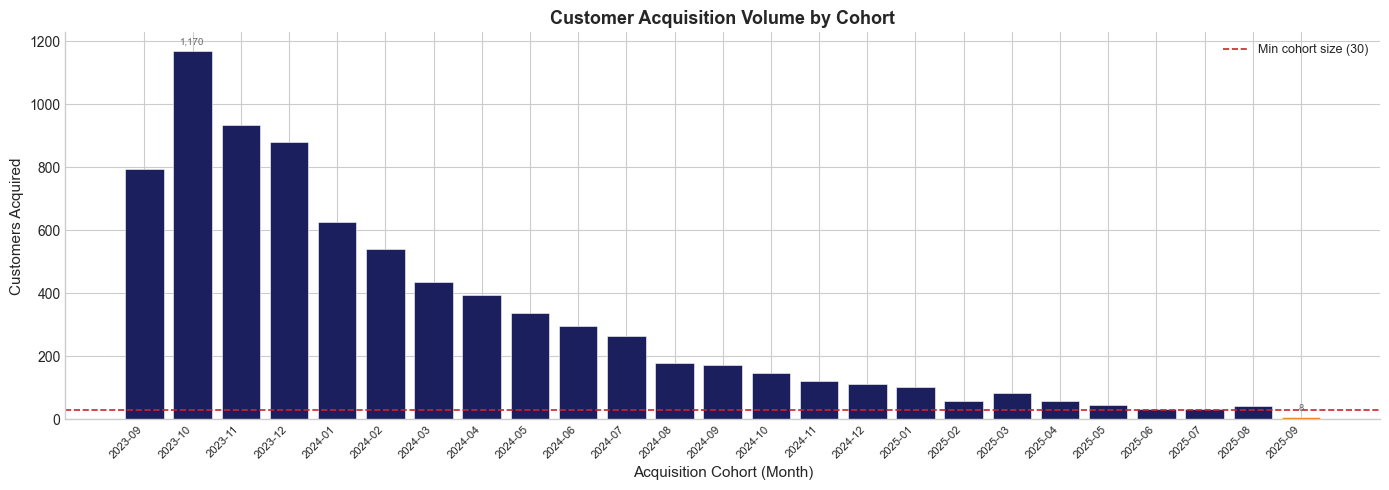


Acquisition Volume Diagnostics:
  Avg monthly growth rate:   -12.8%
  Coefficient of variation:  1.05  (>0.3 = high variability)
  Trend:  Decline | Volume: Volatile


In [4]:
from n6b_cohort_builder import plot_cohort_sizes, compute_acquisition_stats
# compute_acquisition_stats() is a helper in n6b_cohort_builder that returns:
# {'monthly_growth_pct': float, 'cv': float, 'trend': str, 'volume': str}

plot_cohort_sizes(
    cohort_sizes=cohort_sizes,
    low_n_cohorts=low_n_cohorts,
    min_cohort_size=MIN_COHORT_SIZE,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

acq_stats = compute_acquisition_stats(cohort_sizes)

print(f"\nAcquisition Volume Diagnostics:")
print(f"  Avg monthly growth rate:   {acq_stats['monthly_growth_pct']:+.1f}%")
print(f"  Coefficient of variation:  {acq_stats['cv']:.2f}  (>0.3 = high variability)")
print(f"  Trend:  {acq_stats['trend']} | Volume: {acq_stats['volume']}")


## 4. Retention Rate Analysis

Builds the canonical cohort retention heatmap: rows = acquisition cohorts, columns = period offsets, cells = fraction of original cohort still active. The aggregate retention curve (weighted mean across all cohorts, weighted by cohort size) is the primary diagnostic — individual cohort curves isolate outliers and quality variance.

00:40:52 | INFO     | __main__ | Rendering retention heatmap
00:40:52 | INFO     | n6c_retention_viz | [NB06-20260227-004051-CB6E] Rendering retention heatmap
00:40:52 | INFO     | n6c_retention_viz | [NB06-20260227-004051-CB6E] Figure saved: retention_heatmap_NB06-20260227-004051-CB6E.png


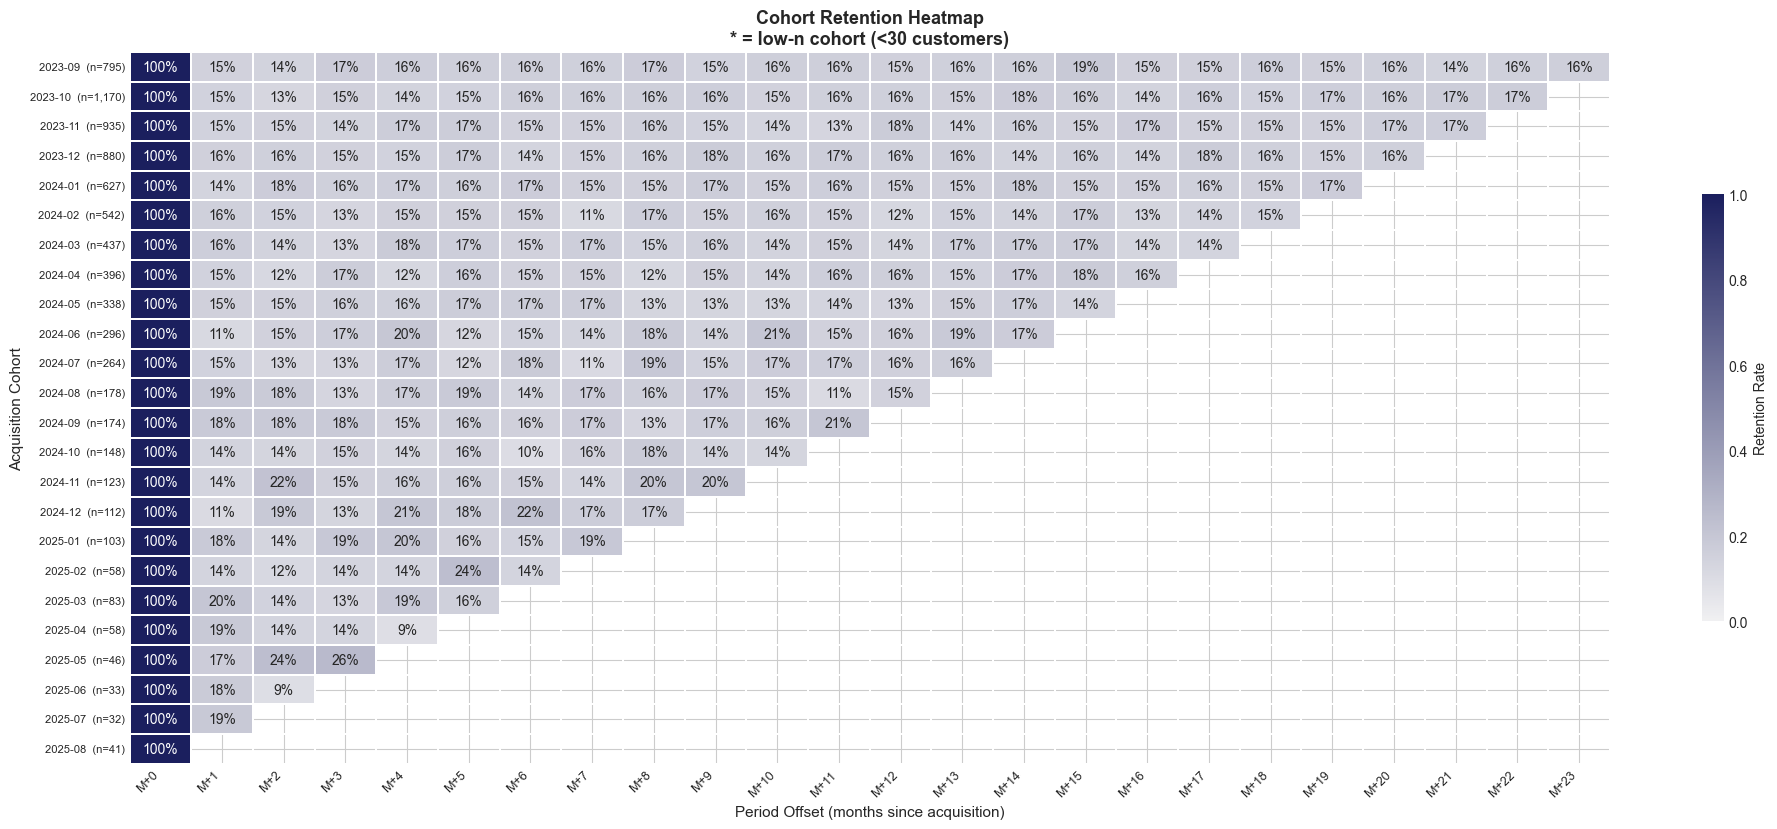


                          AGGREGATE RETENTION PROFILE                           
  Period   Retention   Drop from Prior  Assessment
------------------------------------------------------------
M+    0      100.0%                  —   Healthy
M+    1       15.2%             -84.8%   Below benchmark
M+    2       14.9%              -0.3%   Critical
M+    3       15.3%              +0.4%   Below benchmark
M+    4       16.0%              +0.7%   Below benchmark
M+    5       16.0%              +0.1%   Below benchmark
M+    6       15.6%              -0.4%   Below benchmark
M+    7       15.2%              -0.4%   Below benchmark
M+    8       16.1%              +0.8%   Below benchmark
M+    9       15.8%              -0.3%   Below benchmark
M+   10       15.4%              -0.4%   Below benchmark
M+   11       15.5%              +0.1%   Below benchmark
M+   12       15.4%              -0.1%   Below benchmark
M+   13       15.6%              +0.2%   Below benchmark
M+   14       16.5%    

In [5]:
from n6c_retention_viz import (
    plot_retention_heatmap,
    compute_aggregate_retention
)

logger.info("Rendering retention heatmap")

plot_retention_heatmap(
    retention_matrix=retention_matrix,
    cohort_sizes=cohort_sizes,
    low_n_cohorts=low_n_cohorts,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

# Aggregate retention curve (weighted mean across all cohorts per period offset)
agg_retention = compute_aggregate_retention(retention_matrix, cohort_sizes)

print(f"\n{'='*80}")
print("AGGREGATE RETENTION PROFILE".center(80))
print("=" * 80)
print(f"{'Period':>8}  {'Retention':>10}  {'Drop from Prior':>16}  {'Assessment'}")
print("-" * 60)
for period, row in agg_retention.iterrows():
    ret       = row['retention_rate']
    delta     = row.get('delta', float('nan'))
    delta_str = f"{delta:+.1%}" if not pd.isna(delta) else "—"
    if ret >= HEALTHY_M1_RETENTION:
        flag = "Healthy"
    elif ret >= HEALTHY_M1_RETENTION * 0.6:
        flag = "Below benchmark"
    else:
        flag = "Critical"
    print(f"M+{period:>5}   {ret:>9.1%}   {delta_str:>16}   {flag}")
print("=" * 80)


### 4.1 Retention Curve Overlay

Individual cohort curves overlaid on the weighted aggregate to isolate outperformers and underperformers. A cohort with |z| > 1.5 from the mean retention distribution is flagged as a statistical outlier.

**On recent-cohort outliers:** 2025-08 (z = +3.96) and 2025-07 (z = +1.69) appear as outperformers — but both have only 1–2 observed periods. Apparent outperformance at this stage reflects observation immaturity, not genuine acquisition quality differences. Revisit at M+6 before attributing these to any channel or campaign effect.

00:40:53 | INFO     | n6c_retention_viz | [NB06-20260227-004051-CB6E] Figure saved: retention_curves_NB06-20260227-004051-CB6E.png


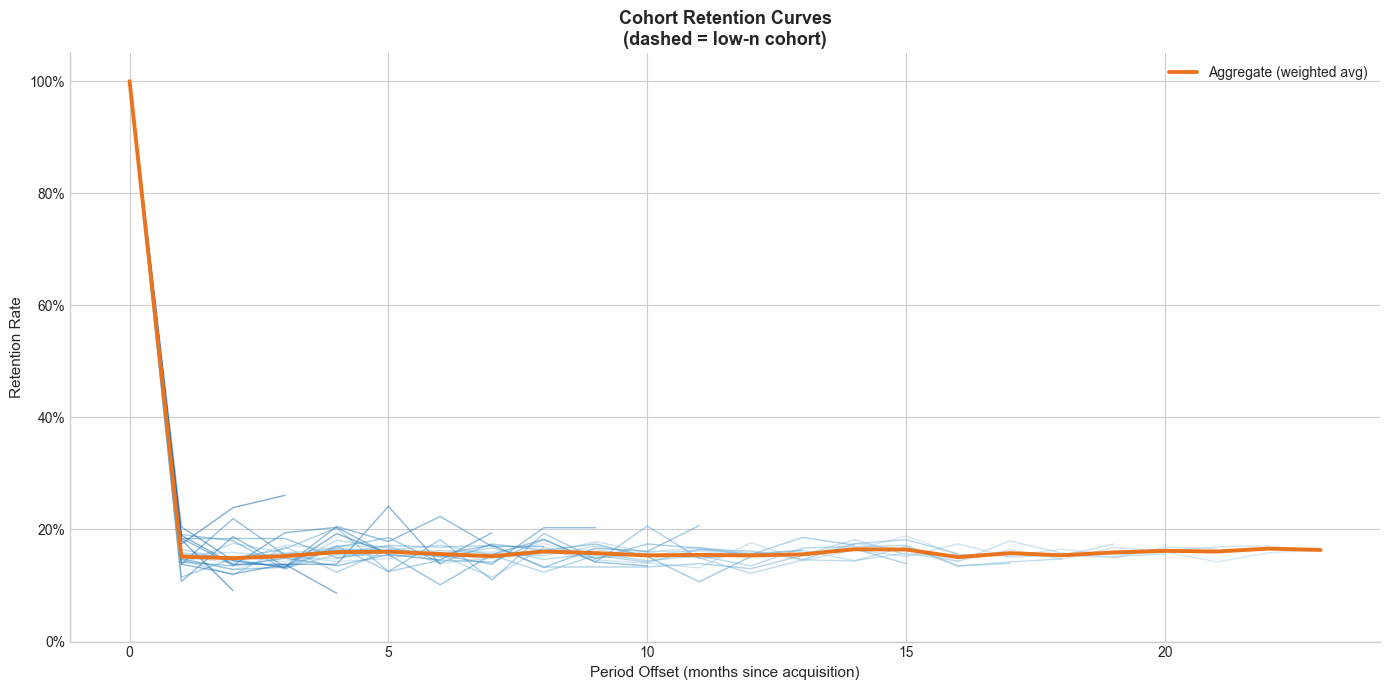


Outlier Cohorts (|z| > 1.5 from mean retention):
-------------------------------------------------------
  2025-08    Outperformer  z = +3.96
  2025-07    Outperformer  z = +1.69


In [6]:
from n6c_retention_viz import plot_retention_curves, identify_retention_outliers

plot_retention_curves(
    retention_matrix=retention_matrix,
    agg_retention=agg_retention,
    low_n_cohorts=low_n_cohorts,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

# Outlier cohorts: |z-score| > 1.5 from mean retention across all periods
outlier_cohorts = identify_retention_outliers(
    retention_matrix=retention_matrix,
    agg_retention=agg_retention,
    z_threshold=stat_cfg.get('outlier_z_threshold', 1.5)
)

if outlier_cohorts:
    print("\nOutlier Cohorts (|z| > 1.5 from mean retention):")
    print("-" * 55)
    for cohort, direction, z_score in outlier_cohorts:
        print(f"  {cohort}  {direction:>14}  z = {z_score:+.2f}")
else:
    print("\nNo significant outlier cohorts — retention is consistent across acquisition periods.")


### 4.2 Dropout Rate Analysis

Period-over-period dropout: what fraction of customers active in period T−1 are gone by period T. Distinct from the retention rate — retention always compares to original cohort size; dropout measures the step-change loss from the surviving base.

**The diagnostic question:** is there a *secondary* dropout spike at M+3 or M+6? A secondary cliff after the initial M+1 loss indicates a structural engagement failure beyond onboarding — loyalty programme gaps, product lifecycle limits, or seasonal repurchase cues that never land.

> **Benchmark context:** Real-world e-commerce M+1 dropout runs 60–75%. An 84.8% reading would indicate a critical post-purchase onboarding failure in a live business. On synthetic data this may partly reflect the generation process — confirm against real transactional data before actioning.

00:40:53 | INFO     | n6c_retention_viz | [NB06-20260227-004051-CB6E] Figure saved: dropout_rates_NB06-20260227-004051-CB6E.png


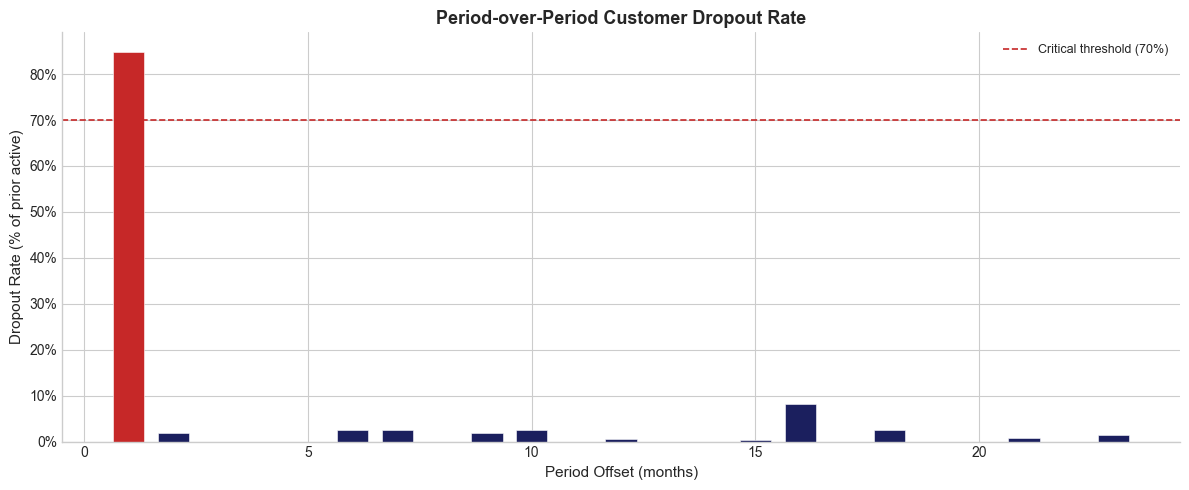


Dropout Inflection Point:
  Peak non-M0 dropout: M+1 (84.8% of prior-period active customers)
  Intervention window closes at: M+0

  Action: Immediate review of post-purchase onboarding and first-reorder triggers.


In [7]:
from n6c_retention_viz import compute_dropout_rates, plot_dropout_rates

dropout_df = compute_dropout_rates(agg_retention)

plot_dropout_rates(
    dropout_df=dropout_df,
    critical_threshold=CRITICAL_DROPOUT_PCT,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

# Inflection point: period with the largest non-M0 dropout rate
m1_plus = dropout_df[dropout_df['period'] > 0].copy()
if len(m1_plus):
    peak = m1_plus.loc[m1_plus['dropout_rate'].idxmax()]
    print(f"\nDropout Inflection Point:")
    print(f"  Peak non-M0 dropout: M+{int(peak['period'])} ({peak['dropout_rate']:.1%} of prior-period active customers)")
    print(f"  Intervention window closes at: M+{max(0, int(peak['period']) - 1)}")

    m1_vals = dropout_df[dropout_df['period'] == 1]['dropout_rate'].values
    if len(m1_vals) and m1_vals[0] >= CRITICAL_DROPOUT_PCT:
        print(f"\n  WARNING: M+1 dropout of {m1_vals[0]:.1%} exceeds critical threshold ({CRITICAL_DROPOUT_PCT:.0%}).")
        print(f"  Action: Immediate review of post-purchase onboarding and first-reorder triggers.")


## 5. Revenue Retention Analysis

Customer count and revenue retention diverge when high-value customers churn at a different rate than the average. A negative spread (revenue trails customer count) signals high-value flight — the most dangerous retention scenario. A positive spread signals that the business disproportionately retains its best customers even as the broader base churns.

This section computes both curves and tests whether retained customers are deepening or narrowing their spend over time.

00:40:53 | INFO     | __main__ | Computing revenue retention matrices
00:40:53 | INFO     | n6d_revenue_retention | [NB06-20260227-004051-CB6E] Building revenue matrix
00:40:53 | INFO     | n6d_revenue_retention | [NB06-20260227-004051-CB6E] Revenue matrix: 24 cohorts x 24 periods
00:40:53 | INFO     | n6d_revenue_retention | Computing revenue retention rates
00:40:53 | INFO     | n6d_revenue_retention | [NB06-20260227-004051-CB6E] Figure saved: revenue_vs_customer_retention_NB06-20260227-004051-CB6E.png


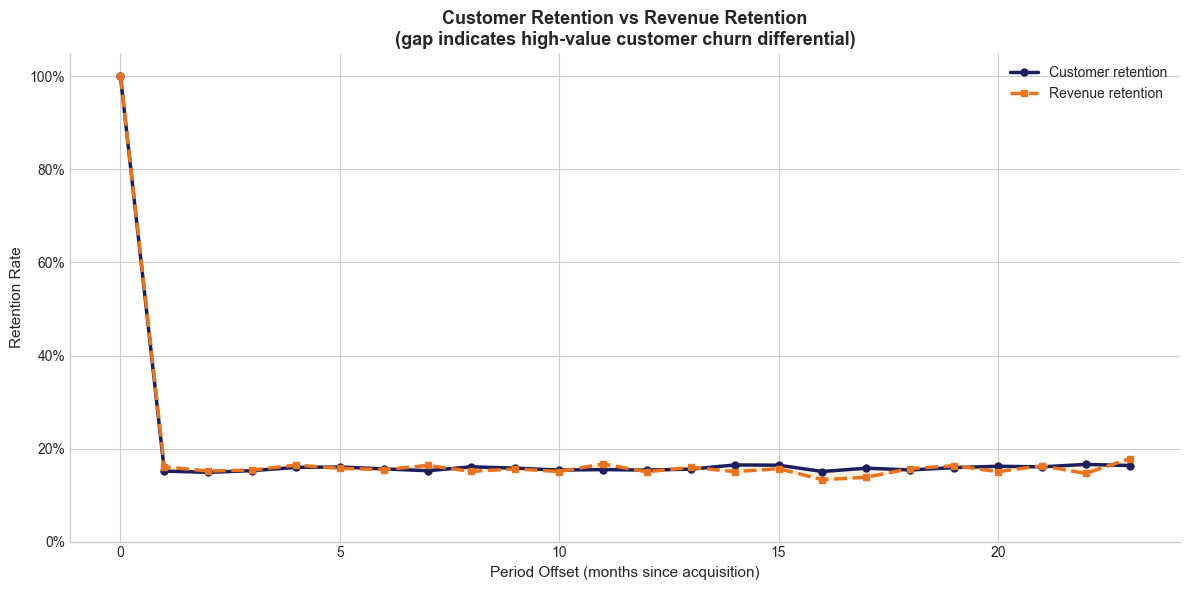


                    REVENUE RETENTION vs CUSTOMER RETENTION                     
  Period    Cust Ret     Rev Ret      Spread  Interpretation
----------------------------------------------------------------------
M+    0      100.0%      100.0%       +0.0%   Proportional churn
M+    1       15.2%       16.1%       +0.9%   Proportional churn
M+    2       14.9%       15.2%       +0.3%   Proportional churn
M+    3       15.3%       15.4%       +0.1%   Proportional churn
M+    4       16.0%       16.4%       +0.5%   Proportional churn
M+    5       16.0%       15.7%       -0.3%   Proportional churn
M+    6       15.6%       15.5%       -0.1%   Proportional churn
M+    7       15.2%       16.4%       +1.1%   Proportional churn
M+    8       16.1%       15.1%       -1.0%   Proportional churn
M+    9       15.8%       15.6%       -0.2%   Proportional churn
M+   10       15.4%       15.1%       -0.3%   Proportional churn
M+   11       15.5%       16.7%       +1.2%   Proportional churn
M+   1

In [8]:
from n6d_revenue_retention import (
    build_revenue_matrix,
    compute_revenue_retention,
    plot_revenue_vs_customer_retention,
    compute_aov_by_period
)

logger.info("Computing revenue retention matrices")

# Revenue matrix: total_amount per cohort per period offset
revenue_matrix = build_revenue_matrix(
    df=df_cohorted,
    incomplete_cutoff=INCOMPLETE_CUTOFF,
    run_id=RUN_ID
)

# Revenue retention — normalized to each cohort's M0 revenue
revenue_retention = compute_revenue_retention(
    revenue_matrix=revenue_matrix,
    cohort_sizes=cohort_sizes
)

# Side-by-side comparison
plot_revenue_vs_customer_retention(
    customer_retention=agg_retention,
    revenue_retention=revenue_retention,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

# AOV by period — do retained customers spend more or less per transaction over time?
aov_by_period = compute_aov_by_period(
    revenue_matrix=revenue_matrix,
    activity_matrix=activity_matrix
)

print(f"\n{'='*80}")
print("REVENUE RETENTION vs CUSTOMER RETENTION".center(80))
print("=" * 80)
print(f"{'Period':>8}  {'Cust Ret':>10}  {'Rev Ret':>10}  {'Spread':>10}  {'Interpretation'}")
print("-" * 70)

for period in sorted(agg_retention.index):
    if period not in revenue_retention.index:
        continue
    c_ret  = agg_retention.loc[period, 'retention_rate']
    r_ret  = revenue_retention.loc[period, 'revenue_retention_rate']
    spread = r_ret - c_ret
    if spread > 0.02:
        interp = "High-value customers retained"
    elif spread < -0.02:
        interp = "High-value customers churning faster"
    else:
        interp = "Proportional churn"
    print(f"M+{period:>5}   {c_ret:>9.1%}   {r_ret:>9.1%}   {spread:>+9.1%}   {interp}")

print("=" * 80)


### 5.1 Average Order Value by Tenure

Tracks whether retained customers spend more or less per transaction as their tenure increases. **Increasing AOV** signals loyalty deepening — longer-tenure customers expand their basket or trade up. **Declining AOV** signals discount dependency or category saturation — customers only return when incentivised, eroding margin.

Spearman ρ used (consistent with distributional findings in NB01) — AOV is right-skewed and Pearson correlation would be inappropriate.

00:40:54 | INFO     | n6d_revenue_retention | [NB06-20260227-004051-CB6E] Figure saved: aov_decay_NB06-20260227-004051-CB6E.png


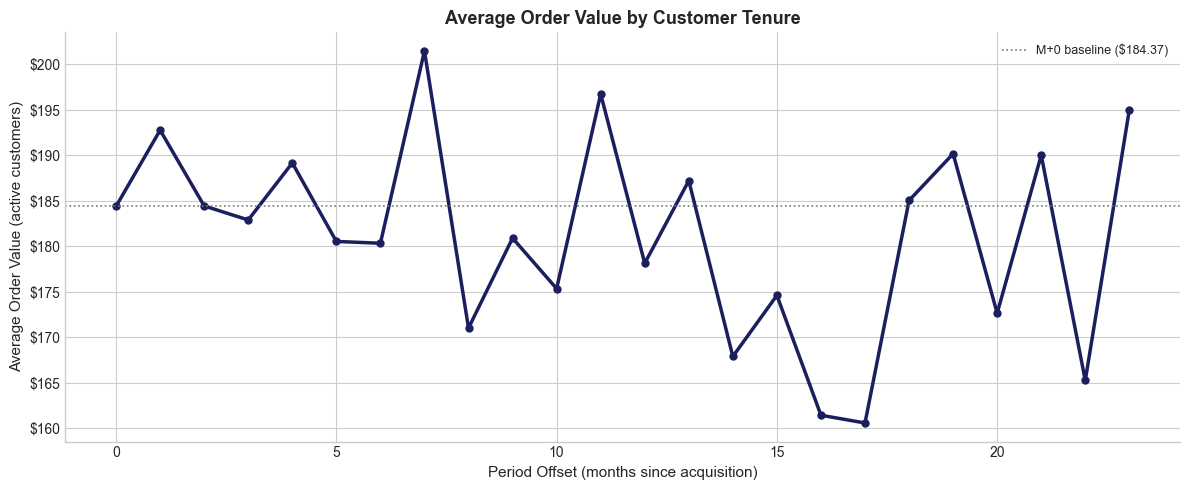


AOV Trend: declining (rho = -0.197, p = 0.357, not statistically significant)
  AOV is stable across customer tenure — no significant drift detected.


In [9]:
from n6d_revenue_retention import plot_aov_decay

plot_aov_decay(
    aov_by_period=aov_by_period,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

# Spearman correlation: AOV vs period offset — direction and significance
if len(aov_by_period) >= 4:
    corr, p_val     = spearmanr(aov_by_period.index, aov_by_period['aov'])
    direction       = 'increasing' if corr > 0 else 'declining'
    significance    = 'significant' if p_val < 0.05 else 'not statistically significant'

    _spearman_thr = stat_cfg.get('spearman_threshold', 0.3)
    _alpha        = stat_cfg.get('alpha', 0.05)

    print(f"\nAOV Trend: {direction} (rho = {corr:.3f}, p = {p_val:.3f}, {significance})")

    if corr < -_spearman_thr and p_val < _alpha:
        print("  Concern: Sustained AOV decline among retained customers.")
        print("  Investigate discount escalation patterns and repeat-purchase category mix.")
    elif corr > _spearman_thr and p_val < _alpha:
        print("  Positive: Long-tenure customers spend more per order.")
        print("  Loyalty mechanics are driving AOV growth — consider expanding the repeat-buyer incentive structure.")
    else:
        print("  AOV is stable across customer tenure — no significant drift detected.")


## 6. Lifetime Value Accumulation

Cumulative LTV per **original cohort member** — not per retained customer. This distinction matters: conditioning on survival (dividing by active customers at each period instead of original cohort size) inflates LTV for older cohorts and makes them incomparable. The definition used here ensures all 25 cohorts are on the same footing regardless of their retention profile.

```
LTV(cohort, t) = Σ revenue[cohort, 0…t]  /  cohort_size[cohort]
```

LTV benchmarks at standard windows (1M / 3M / 6M / 12M) are the primary output for CAC payback calculations and campaign ROI framing.

00:40:54 | INFO     | __main__ | Computing cumulative LTV curves
00:40:54 | INFO     | n6e_ltv | Computing cumulative LTV matrix
00:40:54 | INFO     | n6e_ltv | [NB06-20260227-004051-CB6E] Figure saved: ltv_curves_NB06-20260227-004051-CB6E.png


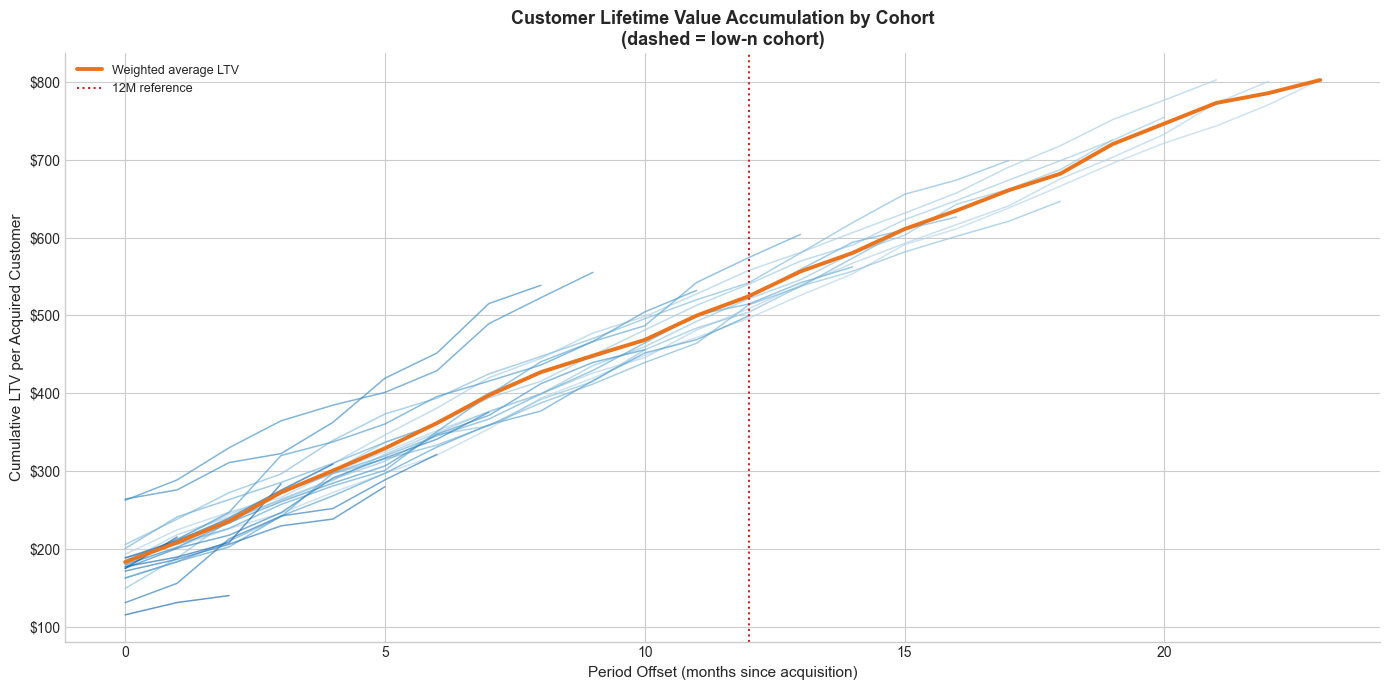


              LTV BENCHMARKS — WEIGHTED AVERAGE ACROSS ALL COHORTS              
  LTV at   1 months:   $    208.33 per customer acquired
  LTV at   3 months:   $    272.67 per customer acquired
  LTV at   6 months:   $    361.71 per customer acquired
  LTV at  12 months:   $    524.58 per customer acquired

LTV Projections (cohorts with < 12 months observed):
  2024-09:  projected 12M LTV = $566.73
  2024-10:  projected 12M LTV = $501.41
  2024-11:  projected 12M LTV = $654.03
  2024-12:  projected 12M LTV = $719.30
  2025-01:  projected 12M LTV = $521.01
  2025-02:  projected 12M LTV = $530.63
  2025-03:  projected 12M LTV = $450.64
  2025-04:  projected 12M LTV = $587.03
  2025-05:  projected 12M LTV = $697.27
  2025-06:  projected 12M LTV = $264.92


In [10]:
from n6e_ltv import (
    compute_cumulative_ltv,
    plot_ltv_curves,
    compute_ltv_benchmarks,
    project_ltv
)

logger.info("Computing cumulative LTV curves")

# Cumulative LTV per cohort, per original customer acquired
ltv_matrix = compute_cumulative_ltv(
    revenue_matrix=revenue_matrix,
    cohort_sizes=cohort_sizes
)

plot_ltv_curves(
    ltv_matrix=ltv_matrix,
    window_months=LTV_WINDOW_MONTHS,
    low_n_cohorts=low_n_cohorts,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

# LTV benchmarks at standard windows
_benchmark_windows = ltv_cfg.get('benchmark_windows', [1, 3, 6, 12])
ltv_benchmarks = compute_ltv_benchmarks(ltv_matrix, windows=_benchmark_windows)

print(f"\n{'='*80}")
print("LTV BENCHMARKS — WEIGHTED AVERAGE ACROSS ALL COHORTS".center(80))
print("=" * 80)
for window, val in ltv_benchmarks.items():
    print(f"  LTV at {window:>3} months:   ${val:>10,.2f} per customer acquired")
print("=" * 80)

# Project LTV for cohorts still within their observation window
ltv_projection = project_ltv(
    ltv_matrix=ltv_matrix,
    target_window=LTV_WINDOW_MONTHS,
    incomplete_cutoff=INCOMPLETE_CUTOFF
)

if ltv_projection:
    print(f"\nLTV Projections (cohorts with < {LTV_WINDOW_MONTHS} months observed):")
    for cohort, projected_val in ltv_projection.items():
        print(f"  {cohort}:  projected {LTV_WINDOW_MONTHS}M LTV = ${projected_val:,.2f}")


### 6.1 Reading the LTV Curves

| Signal | What it means | Implication |
|---|---|---|
| Curves flatten before M+4 | Most value captured in acquisition month | Single-purchase dynamics dominant — subscription or replenishment programme warranted |
| Curves compound past M+6 | Genuine repeat-purchase behaviour | Retention infrastructure pays — extend the compounding window |
| High variance across cohorts | Acquisition quality or channel mix varies | Investigate cohort-period coincidences (campaigns, seasonality) |
| Tight curve clustering | Consistent acquisition quality | Retention optimisation is the lever — not acquisition targeting |
| Projections > 1.5× benchmark | Immature cohort with steep early slope | Extrapolation unreliable — treat as directional only, revisit at M+6 |

**Payback period:** if CAC is available → `Payback months = CAC ÷ M+1 LTV per customer`. Benchmark: payback within 6 months is healthy for e-commerce with repeat-purchase potential.

## 7. Segment-Level Retention

Aggregate M+1 retention of 15.2% is a population average — it obscures whether the dropout problem is universal or concentrated in a specific customer type. Three stratifications follow: **RFM loyalty tier** (NB01 quartiles), **NB03 behavioural cluster** (k-means segments), and **first-purchase product category**.

00:40:54 | INFO     | __main__ | Computing segment-level retention
00:40:54 | INFO     | n6f_segment_retention | Loyalty tiers assigned: {'Bronze': np.int64(1970), 'Silver': np.int64(1969), 'Gold': np.int64(1969), 'Platinum': np.int64(1969)}
00:40:54 | INFO     | n6f_segment_retention | [NB06-20260227-004051-CB6E] Figure saved: retention_by_segment_NB06-20260227-004051-CB6E.png


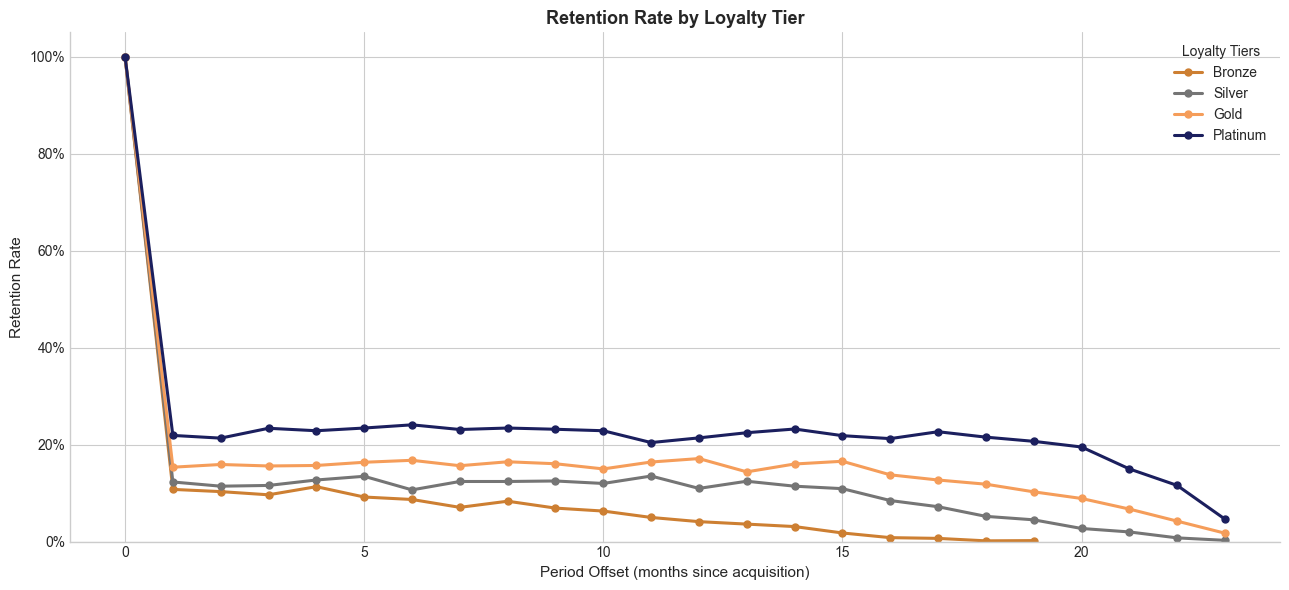


                        RETENTION & LTV BY LOYALTY TIER                         
Tier           Customers   M+1 Ret   M+3 Ret       12M LTV
------------------------------------------------------------
Bronze             1,970    10.8%     9.6%  $    300.64
Silver             1,969    12.3%    11.6%  $    382.05
Gold               1,969    15.3%    15.6%  $    507.58
Platinum           1,969    21.9%    23.4%  $    850.79


In [11]:
from n6f_segment_retention import (
    attach_rfm_segments,
    assign_loyalty_tiers,   # NEW: extracted from notebook — src/n6f_segment_retention.py
    compute_segment_retention,
    plot_retention_by_segment,
    compute_segment_ltv
)

logger.info("Computing segment-level retention")

# Assign loyalty tier from rfm_df using NB01 loyalty_segments labels.
# Previously inline pd.qcut — now delegated to n6f_segment_retention.assign_loyalty_tiers()
# so that the same binning logic is reusable across notebooks.
loyalty_labels = config['notebook1']['loyalty_segments']['labels']
rfm_df = assign_loyalty_tiers(
    rfm_df=rfm_df,
    loyalty_labels=loyalty_labels
)

df_segmented = attach_rfm_segments(
    df_cohorted=df_cohorted,
    rfm_df=rfm_df,
    segment_col='loyalty_tier',
    run_id=RUN_ID
)

# Retention rates by loyalty tier
segment_retention = compute_segment_retention(
    df=df_segmented,
    segment_col='loyalty_tier',
    incomplete_cutoff=INCOMPLETE_CUTOFF
)

plot_retention_by_segment(
    segment_retention=segment_retention,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True,
    segment_type='loyalty_tiers',
    title='Retention Rate by Loyalty Tier',
)

# LTV by loyalty tier — windows from config
_segment_windows = ltv_cfg.get('segment_windows', [3, 6, 12])
segment_ltv = compute_segment_ltv(
    df=df_segmented,
    segment_col='loyalty_tier',
    incomplete_cutoff=INCOMPLETE_CUTOFF,
    windows=_segment_windows
)

print(f"\n{'='*80}")
print("RETENTION & LTV BY LOYALTY TIER".center(80))
print("=" * 80)
print(f"{'Tier':<12}  {'Customers':>10}  {'M+1 Ret':>8}  {'M+3 Ret':>8}  {'12M LTV':>12}")
print("-" * 60)
for tier in loyalty_labels:
    if tier not in segment_retention or tier not in segment_ltv:
        continue
    sr  = segment_retention[tier]
    sl  = segment_ltv[tier]
    n   = int(rfm_df[rfm_df['loyalty_tier'] == tier].shape[0])
    m1  = sr.get(1, float('nan'))
    m3  = sr.get(3, float('nan'))
    l12 = sl.get(12, float('nan'))
    print(f"{tier:<12}  {n:>10,}  {m1:>7.1%}  {m3:>7.1%}  ${l12:>10,.2f}")
print("=" * 80)


### 7.1 Retention by NB03 Cluster Segment

Cross-references the four behavioural segments from NB03 k-means clustering — **Loyal Customers, High-Value at Risk, Needs Engagement, Lost Customers** — with their cohort retention trajectories. This links the *snapshot* segmentation (who they are today) with the *lifecycle* view (how they behaved from day one).

The key test: does **High-Value at Risk** (480 customers · $2,237 12M LTV · NB03 finding: mean recency 153 days) show a retention cliff at M+5 or M+6? If so, it corroborates NB03's structural decline finding. If not — if HVAR retention is merely lower but flat — it suggests recency gap rather than progressive disengagement.

> `customer_segments.csv` required from NB03 `data/processed/`. Falls back gracefully if file is absent.

NB03 segments matched: 7,903 / 7,903 customers (100.0%)
00:40:54 | INFO     | n6f_segment_retention | [NB06-20260227-004051-CB6E] Figure saved: retention_by_segment_NB06-20260227-004051-CB6E.png


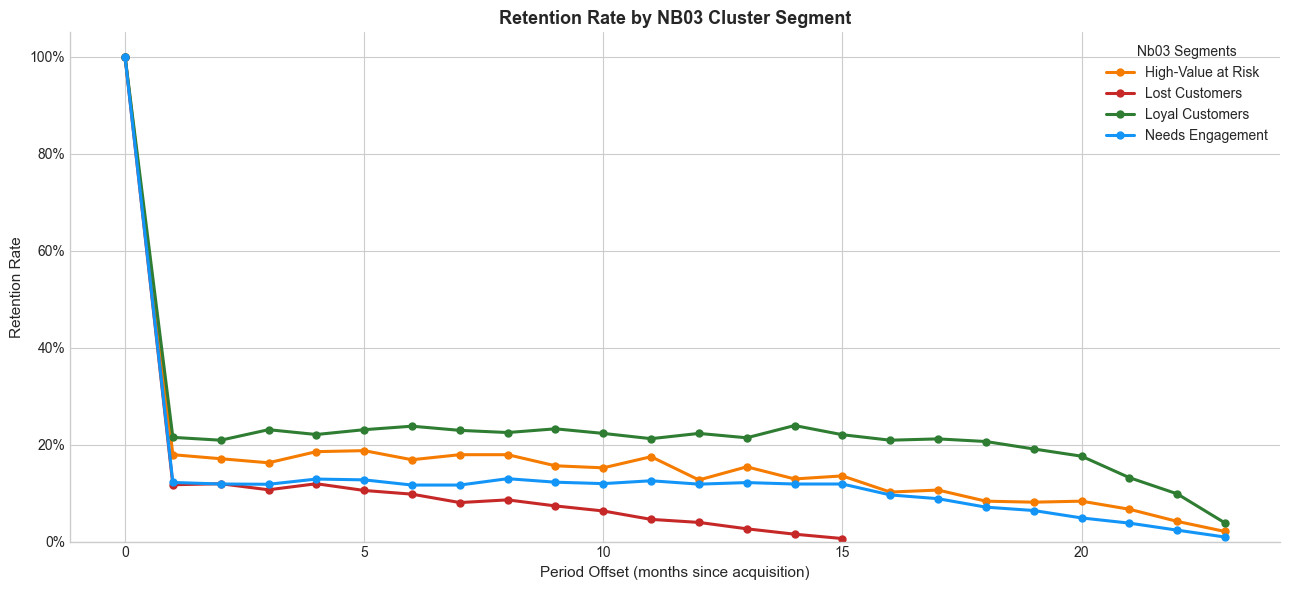


                    RETENTION & LTV BY NB03 CLUSTER SEGMENT                     
Segment                  Customers   M+1 Ret   M+3 Ret   M+6 Ret       12M LTV
------------------------------------------------------------------------------
Loyal Customers              2,215    21.5%    23.1%    23.8%  $    647.82
High-Value at Risk             480    17.9%    16.2%    16.9%  $  2,237.46
Needs Engagement             3,766    12.2%    11.8%    11.7%  $    297.98
Lost Customers               1,442    11.7%    10.7%     9.8%  $    274.01

Retention Gap: Loyal Customers vs High-Value at Risk
--------------------------------------------------
  M+0    Loyal=100.0%  HVAR=100.0%  gap=+0.0%  
  M+1    Loyal=21.5%  HVAR=17.9%  gap=+3.6%  ###
  M+2    Loyal=20.9%  HVAR=17.1%  gap=+3.8%  ###
  M+3    Loyal=23.1%  HVAR=16.2%  gap=+6.8%  ######
  M+4    Loyal=22.1%  HVAR=18.5%  gap=+3.5%  ###
  M+5    Loyal=23.1%  HVAR=18.8%  gap=+4.3%  ####
  M+6    Loyal=23.8%  HVAR=16.9%  gap=+6.9%  ######
  M+7 

In [12]:
# ── NB03 Segment-Level Retention ──────────────────────────────────────────
# Load NB03 cluster assignments and merge onto cohorted transactions
# Requires: data/processed/customer_segments.csv (output of NB03)

from pathlib import Path

segments_path = PROJECT_ROOT / 'data' / 'processed' / 'customer_segments.csv'

if segments_path.exists():
    nb03_segments = pd.read_csv(segments_path)[['customer_id', 'segment_name']]
    nb03_segments = nb03_segments.drop_duplicates('customer_id')

    # Merge NB03 segment labels onto rfm_df for attach_rfm_segments
    rfm_with_nb03 = rfm_df.merge(nb03_segments, on='customer_id', how='left')

    n_matched = rfm_with_nb03['segment_name'].notna().sum()
    n_total   = len(rfm_with_nb03)
    print(f'NB03 segments matched: {n_matched:,} / {n_total:,} customers '
          f'({n_matched/n_total:.1%})')

    # Attach NB03 segment to cohorted transactions
    df_nb03_segmented = attach_rfm_segments(
        df_cohorted=df_cohorted,
        rfm_df=rfm_with_nb03,
        segment_col='segment_name',
        run_id=RUN_ID
    )

    # Compute retention curves per NB03 segment
    nb03_segment_retention = compute_segment_retention(
        df=df_nb03_segmented,
        segment_col='segment_name',
        incomplete_cutoff=INCOMPLETE_CUTOFF
    )

    plot_retention_by_segment(
        segment_retention=nb03_segment_retention,
        config=config,
        run_id=RUN_ID,
        save=True,
        show=True,
        segment_type='nb03_segments',
        title='Retention Rate by NB03 Cluster Segment',
    )

    # LTV by NB03 segment
    _nb03_windows    = ltv_cfg.get('nb03_segment_windows', [1, 3, 6, 12])
    nb03_segment_ltv = compute_segment_ltv(
        df=df_nb03_segmented,
        segment_col='segment_name',
        incomplete_cutoff=INCOMPLETE_CUTOFF,
        windows=_nb03_windows
    )

    # Segment display order — from config (notebook6.nb03_segments.order)
    segment_order = nb03_cfg.get(
        'order',
        ['Loyal Customers', 'High-Value at Risk', 'Needs Engagement', 'Lost Customers']
    )

    print(f"\n{'='*80}")
    print('RETENTION & LTV BY NB03 CLUSTER SEGMENT'.center(80))
    print('=' * 80)
    print(f"{'Segment':<22}  {'Customers':>10}  {'M+1 Ret':>8}  "
          f"{'M+3 Ret':>8}  {'M+6 Ret':>8}  {'12M LTV':>12}")
    print('-' * 78)

    for seg in segment_order:
        if seg not in nb03_segment_retention:
            continue
        sr  = nb03_segment_retention[seg]
        sl  = nb03_segment_ltv.get(seg, {})
        n   = int(nb03_segments[nb03_segments['segment_name'] == seg].shape[0])
        m1  = sr.get(1,  float('nan'))
        m3  = sr.get(3,  float('nan'))
        m6  = sr.get(6,  float('nan'))
        l12 = sl.get(12, float('nan'))
        print(f"{seg:<22}  {n:>10,}  {m1:>7.1%}  {m3:>7.1%}  "
              f"{m6:>7.1%}  ${l12:>10,.2f}")

    print('=' * 80)

    # Key insight: compare Loyal vs High-Value at Risk dropout timing
    loyal_ret = nb03_segment_retention.get('Loyal Customers', {})
    hvar_ret  = nb03_segment_retention.get('High-Value at Risk', {})

    if loyal_ret and hvar_ret:
        common_periods = sorted(set(loyal_ret) & set(hvar_ret))
        if common_periods:
            print('\nRetention Gap: Loyal Customers vs High-Value at Risk')
            print('-' * 50)
            _compare_n = nb03_cfg.get('comparison_periods', 9)
            for p in common_periods[:_compare_n]:
                gap = loyal_ret.get(p, 0) - hvar_ret.get(p, 0)
                bar = '#' * int(abs(gap) * 100)
                print(f'  M+{p:<3}  Loyal={loyal_ret.get(p,0):.1%}  '
                      f'HVAR={hvar_ret.get(p,0):.1%}  gap={gap:+.1%}  {bar}')

else:
    print('⚠️  customer_segments.csv not found at expected path:')
    print(f'   {segments_path}')
    print('   Run NB03 first and ensure customer_segments.csv is saved '
          'to data/processed/.')
    nb03_segment_retention = {}
    nb03_segment_ltv       = {}


### 7.2 Retention by First-Purchase Category

The product category a customer buys first is a leading indicator of long-run engagement — a Grocery first-purchaser is satisfying a recurring need and is structurally likely to return; an Electronics first-purchaser may be making a one-time high-value purchase with no natural repurchase trigger.

A wide spread across categories would support category-specific onboarding sequences. A narrow spread suggests the onboarding gap is universal — no category provides enough structural pull to meaningfully change retention odds.

00:40:55 | INFO     | n6f_segment_retention | Computing first-purchase category per customer
00:40:55 | INFO     | n6f_segment_retention | [NB06-20260227-004051-CB6E] Figure saved: category_retention_NB06-20260227-004051-CB6E.png


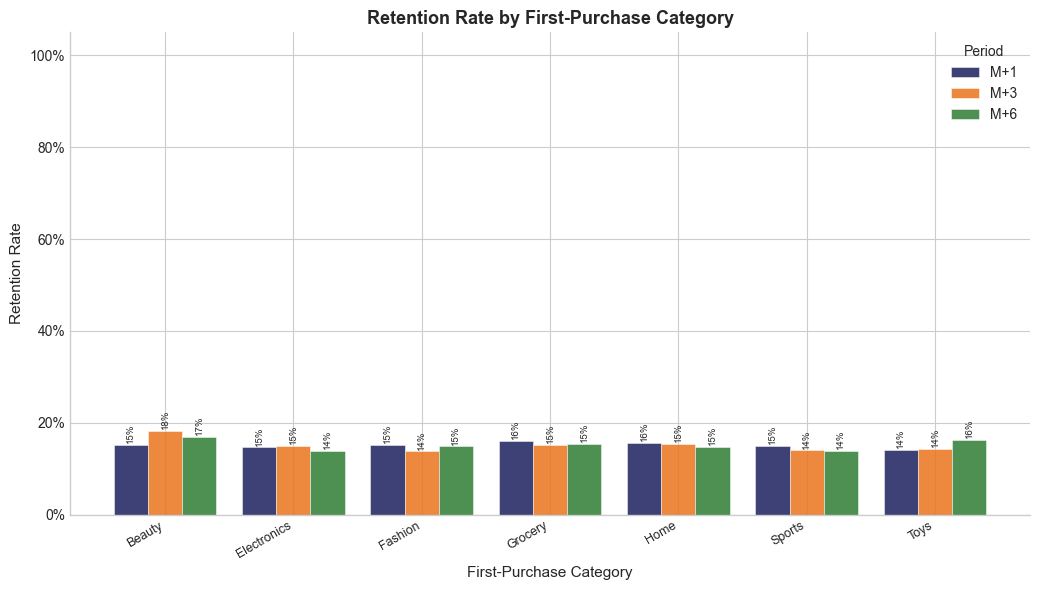


Category Retention Ranking (M+1):
  Grocery                     16.0%  ######
  Home                        15.5%  ######
  Beauty                      15.2%  ######
  Fashion                     15.2%  ######
  Sports                      14.9%  #####
  Electronics                 14.6%  #####
  Toys                        14.0%  #####

  Best:   Grocery (16.0%)
  Worst:  Toys (14.0%)
  Spread: 2.0% — Modest category effect on early retention


In [13]:
from n6f_segment_retention import (
    compute_first_category,
    plot_category_retention_comparison
)

# Identify each customer's first non-returned purchase category
df_with_first_cat = compute_first_category(
    df=df_cohorted,
    customer_id_col='customer_id',
    date_col='order_date',
    category_col='category',
    returned_col='returned'
)

# Retention stratified by first-purchase category
cat_retention = compute_segment_retention(
    df=df_with_first_cat,
    segment_col='first_category',
    incomplete_cutoff=INCOMPLETE_CUTOFF
)

plot_category_retention_comparison(
    cat_retention=cat_retention,
    periods=[1, 3, 6],
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

# Summary: rank categories by M+1 retention
m1_by_cat = {cat: ret.get(1, float('nan')) for cat, ret in cat_retention.items()}
m1_by_cat = {k: v for k, v in m1_by_cat.items() if not pd.isna(v)}

if m1_by_cat:
    best_cat  = max(m1_by_cat, key=m1_by_cat.get)
    worst_cat = min(m1_by_cat, key=m1_by_cat.get)
    spread    = m1_by_cat[best_cat] - m1_by_cat[worst_cat]

    print(f"\nCategory Retention Ranking (M+1):")
    for cat, rate in sorted(m1_by_cat.items(), key=lambda x: -x[1]):
        bar = '#' * int(rate * 40)
        print(f"  {cat:<25}  {rate:>6.1%}  {bar}")
    print(f"\n  Best:   {best_cat} ({m1_by_cat[best_cat]:.1%})")
    print(f"  Worst:  {worst_cat} ({m1_by_cat[worst_cat]:.1%})")
    print(f"  Spread: {spread:.1%} — {'Material' if spread > 0.05 else 'Modest'} category effect on early retention")


## 8. Statistical Validation

Non-parametric tests throughout — no normality assumption, consistent with distributional findings established in NB01 (Shapiro-Wilk p < 0.001 on all four transaction variables).

**Omnibus question:** are between-cohort retention differences real signal or sampling noise? If cohorts differ significantly, the problem is episodic — tied to specific acquisition periods, channels, or campaigns — and requires cohort-specific interventions. If not, the problem is structural and a universal solution applies.

00:40:55 | INFO     | __main__ | Running statistical validation
00:40:55 | INFO     | n6g_stats | Kruskal-Wallis (period=1): H=22.0000, p=0.4599, significant=False

          STATISTICAL VALIDATION: BETWEEN-COHORT RETENTION DIFFERENCES          
  Test:         Kruskal-Wallis (M+1 retention rates across cohorts)
  H-statistic:  22.0000
  p-value:      0.4599
  Conclusion:   No significant differences — acquisition quality is consistent across cohorts

00:40:55 | INFO     | n6g_stats | [NB06-20260227-004051-CB6E] Figure saved: retention_variance_NB06-20260227-004051-CB6E.png


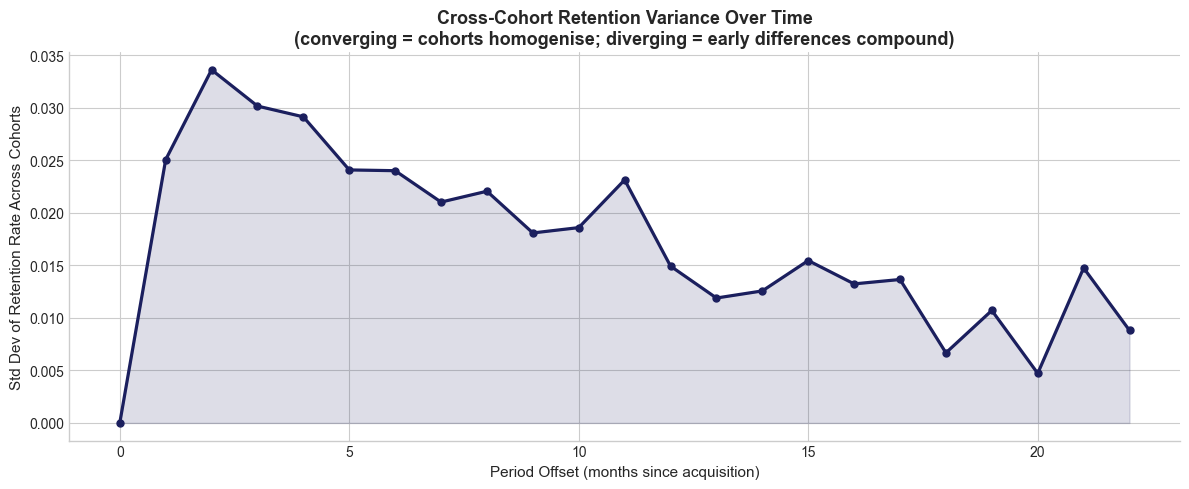

  Cross-Cohort Retention Variance by Period (std dev):
    Period     Std Dev  Trend
  M+    0       0.000   —
  M+    1       0.025   diverging
  M+    2       0.034   diverging
  M+    3       0.030   converging
  M+    4       0.029   converging
  M+    5       0.024   converging
  M+    6       0.024   converging
  M+    7       0.021   converging
  M+    8       0.022   diverging
  M+    9       0.018   converging
  M+   10       0.019   diverging
  M+   11       0.023   diverging
  M+   12       0.015   converging
  M+   13       0.012   converging
  M+   14       0.013   diverging
  M+   15       0.015   diverging
  M+   16       0.013   converging
  M+   17       0.014   diverging
  M+   18       0.007   converging
  M+   19       0.011   diverging
  M+   20       0.005   converging
  M+   21       0.015   diverging
  M+   22       0.009   converging


In [14]:
from n6g_stats import (
    kruskal_retention_test,
    pairwise_cohort_comparison,
    compute_retention_stability,
    plot_retention_variance
)

logger.info("Running statistical validation")

# Omnibus test: do cohorts differ significantly in M+1 retention?
kw_result = kruskal_retention_test(
    retention_matrix=retention_matrix,
    period=1,
    alpha=0.05
)

print(f"\n{'='*80}")
print("STATISTICAL VALIDATION: BETWEEN-COHORT RETENTION DIFFERENCES".center(80))
print("=" * 80)
print(f"  Test:         Kruskal-Wallis (M+1 retention rates across cohorts)")
print(f"  H-statistic:  {kw_result['statistic']:.4f}")
print(f"  p-value:      {kw_result['p_value']:.4f}")
print(f"  Conclusion:   {'Significant differences exist between cohorts — investigate root causes' if kw_result['significant'] else 'No significant differences — acquisition quality is consistent across cohorts'}")

if kw_result['significant']:
    print(f"\n  Follow-up pairwise comparisons (Mann-Whitney, Bonferroni-corrected):")
    pairwise_results = pairwise_cohort_comparison(
        retention_matrix=retention_matrix,
        period=1,
        alpha=0.05
    )
    sig_pairs = [(a, b, p) for a, b, p in pairwise_results if p < 0.05]
    print(f"  Significant pairs: {len(sig_pairs)} of {len(pairwise_results)}")
    for a, b, p in sig_pairs[:5]:
        print(f"    {a} vs {b}: p = {p:.4f}")

print()

# Retention variance over time — does cross-cohort spread increase or decrease as cohorts age?
stability = compute_retention_stability(retention_matrix)

plot_retention_variance(
    stability=stability,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

print("  Cross-Cohort Retention Variance by Period (std dev):")
print(f"  {'Period':>8}  {'Std Dev':>10}  {'Trend'}")
prev = None
for period, std in stability.items():
    trend = 'converging' if (prev is not None and std < prev) else ('diverging' if prev is not None else '—')
    print(f"  M+{period:>5}   {std:>9.3f}   {trend}")
    prev = std
print("=" * 80)


## 9. Business Insights & Recommendations

Synthesises cohort, revenue, and LTV findings into prioritised, metric-anchored recommendations. Each insight is auto-generated against thresholds from `config.yaml → notebook6.business_rules` — findings update dynamically if run on a different dataset.

00:40:55 | INFO     | n6h_insights | [NB06-20260227-004051-CB6E] 4 insights generated
00:40:55 | INFO     | n6h_insights | [NB06-20260227-004051-CB6E] Figure saved: insights_summary_NB06-20260227-004051-CB6E.png


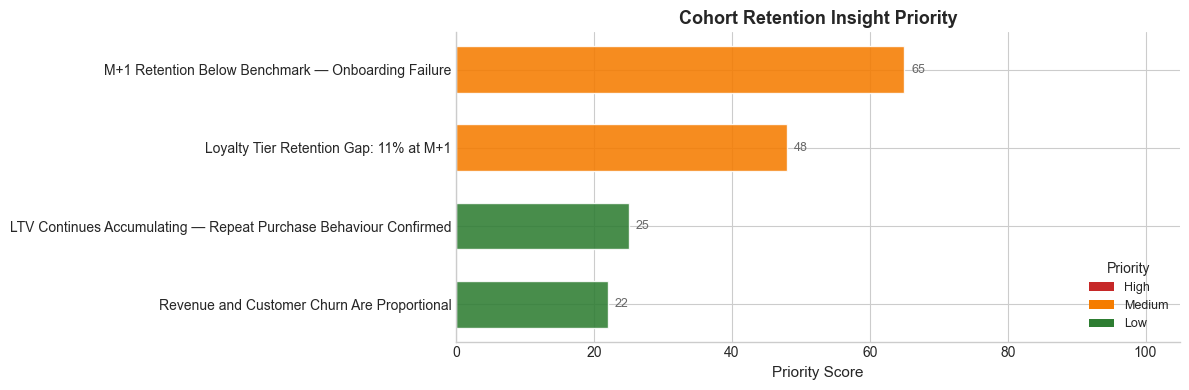


                           COHORT RETENTION INSIGHTS                            

  [1] M+1 Retention Below Benchmark — Onboarding Failure
      Finding:   First-month retention of 15.2% is 9.8% below the 25% benchmark. This corresponds to an M+1 dropout rate of 84.8% — the steepest single-period customer loss in the analysis window.
      Metric:    M+1 retention = 15.2% (benchmark: 25%); M+1 dropout = 84.8%
      Action:    Implement a post-purchase onboarding sequence triggered within 7 days of first order. Target a second-purchase incentive (e.g. 10% off next order, personalised recommendation email). A/B test incentive vs non-incentive messaging to isolate the effect.
      Priority:  Medium

  [2] Loyalty Tier Retention Gap: 11% at M+1
      Finding:   Platinum tier retains at 21.9% vs Bronze tier at 10.8% — a 11% gap that compounds over the LTV window.
      Metric:    M+1 retention gap (Platinum vs Bronze) = 11.1%
      Action:    Prioritise Bronze-tier upgrade pathways: offer

In [15]:
from n6h_insights import generate_cohort_insights, plot_insights_summary

insights = generate_cohort_insights(
    retention_matrix=retention_matrix,
    revenue_retention=revenue_retention,
    agg_retention=agg_retention,
    ltv_matrix=ltv_matrix,
    segment_retention=segment_retention,
    ltv_benchmarks=ltv_benchmarks,
    dropout_df=dropout_df,
    config=config,
    run_id=RUN_ID
)

plot_insights_summary(
    insights=insights,
    config=config,
    run_id=RUN_ID,
    save=True,
    show=True
)

print(f"\n{'='*80}")
print("COHORT RETENTION INSIGHTS".center(80))
print("=" * 80)
for i, insight in enumerate(insights, 1):
    print(f"\n  [{i}] {insight['title']}")
    print(f"      Finding:   {insight['finding']}")
    print(f"      Metric:    {insight['metric']}")
    print(f"      Action:    {insight['action']}")
    print(f"      Priority:  {insight['priority']}")
print("\n" + "=" * 80)


### 9.1 Retention Improvement Scenarios

Translates retention improvements into annual revenue uplift — the input needed to build a business case for onboarding investment. Formula: `extra_customers × LTV(period) × 12 cohorts`, applied uniformly across projected future acquisition at current average cohort size.

Use **M+3 figures** for 90-day campaign ROI framing. Use **M+1 figures** for onboarding programme business cases where the goal is triggering a second purchase within 30 days.

In [16]:
from n6h_insights import compute_retention_scenarios

_improvement_increments = scen_cfg.get('improvement_increments', [0.05, 0.10, 0.15])
_scenario_periods       = scen_cfg.get('periods', [1, 3])

scenarios = compute_retention_scenarios(
    agg_retention=agg_retention,
    ltv_benchmarks=ltv_benchmarks,
    cohort_sizes=cohort_sizes,
    improvement_increments=_improvement_increments,
    periods=_scenario_periods
)

print(f"\n{'='*80}")
print("RETENTION IMPROVEMENT — ESTIMATED ANNUAL REVENUE UPLIFT".center(80))
print("=" * 80)
print(f"  {'Improvement':>12}  {'At M+1':>15}  {'At M+3':>15}")
print("-" * 50)
for scenario in scenarios:
    print(f"  {scenario['increment']:>+11.0%}   ${scenario['m1_uplift']:>13,.0f}   ${scenario['m3_uplift']:>13,.0f}")
print("=" * 80)
print(f"\n  Basis: Applied uniformly to all projected future cohorts at current avg size.")
print(f"  Use M+3 figure for 90-day campaign ROI framing; M+1 for onboarding program business cases.")



            RETENTION IMPROVEMENT — ESTIMATED ANNUAL REVENUE UPLIFT             
   Improvement           At M+1           At M+3
--------------------------------------------------
          +5%   $       39,384   $       51,548
         +10%   $       78,768   $      103,097
         +15%   $      118,152   $      154,645

  Basis: Applied uniformly to all projected future cohorts at current avg size.
  Use M+3 figure for 90-day campaign ROI framing; M+1 for onboarding program business cases.


## 10. Data Quality Validation

Systematic checks against all four output DataFrames before any file is written. M+0 retention enforced at 1.0 for all cohorts · retention values bounded [0, 1] · no negative revenue or LTV cells · all retention matrix cohorts have a corresponding size record. **Pipeline halts on any FAIL** — downstream notebooks and dashboards should not consume matrices with invalid cells.

In [17]:
from n6i_validation import validate_cohort_outputs

validation_results = validate_cohort_outputs(
    df_cohorted=df_cohorted,
    retention_matrix=retention_matrix,
    revenue_matrix=revenue_matrix,
    ltv_matrix=ltv_matrix,
    cohort_sizes=cohort_sizes,
    config=config,
    run_id=RUN_ID,
    verbose=True
)

print(f"\n{'='*80}")
print("COHORT OUTPUT VALIDATION RESULTS".center(80))
print("=" * 80)
print(f"  Total Checks:  {validation_results['total_checks']}")
print(f"  Passed:        {validation_results['passed_checks']}")
print(f"  Failed:        {validation_results['failed_checks']}")
print(f"  Warnings:      {validation_results['warning_checks']}")

if validation_results['all_passed']:
    print(f"\n  DATA QUALITY GATE: PASSED")
    print(f"  All cohort outputs are consistent and ready for downstream use")
else:
    print(f"\n  DATA QUALITY GATE: FAILED")
    print(f"  Address the following before saving outputs:")
    for msg in validation_results.get('messages', []):
        print(f"  - {msg}")

print("=" * 80)


00:40:55 | INFO     | n6i_validation | [NB06-20260227-004051-CB6E] PASS — df_cohorted has cohort_month column: Columns: ['order_id', 'customer_id', 'product_id', 'category', 'price']...
  [PASS] df_cohorted has cohort_month column                     Columns: ['order_id', 'customer_id', 'product_id', 'category', 'price']...
00:40:55 | INFO     | n6i_validation | [NB06-20260227-004051-CB6E] PASS — df_cohorted has period_offset column: Columns: ['order_id', 'customer_id', 'product_id', 'category', 'price']...
  [PASS] df_cohorted has period_offset column                    Columns: ['order_id', 'customer_id', 'product_id', 'category', 'price']...
00:40:55 | INFO     | n6i_validation | [NB06-20260227-004051-CB6E] PASS — No null cohort_month values: 0 null cohort_month rows
  [PASS] No null cohort_month values                             0 null cohort_month rows
00:40:55 | INFO     | n6i_validation | [NB06-20260227-004051-CB6E] PASS — No negative period_offset values: 0 negative period off

## 11. Save Outputs

Four Parquet files persisted to `data/processed/`. Index and column names cast to string before saving — `Period[M]` objects are not universally supported by all Parquet readers and would fail silently in some BI tools.

`cohort_summary.parquet` is the recommended consumption layer for dashboards — one clean row per cohort with M+1, M+3, M+6 retention and 3M, 6M, 12M LTV pre-computed.

In [18]:
from n6j_data_saver import save_cohort_outputs

saved_files = save_cohort_outputs(
    df_cohorted=df_cohorted,
    retention_matrix=retention_matrix,
    revenue_matrix=revenue_matrix,
    ltv_matrix=ltv_matrix,
    segment_ltv=segment_ltv,
    config=config,
    run_id=RUN_ID,
    verbose=True
)

print(f"\n{'='*80}")
print("PIPELINE OUTPUTS".center(80))
print("=" * 80)
print("Data Files Ready:")
for name, filepath in saved_files.items():
    file_size = filepath.stat().st_size / 1024 / 1024
    print(f"  {name:<28}  {filepath.name}  ({file_size:.2f} MB)")
print("=" * 80)


00:40:55 | INFO     | n6j_data_saver | [NB06-20260227-004051-CB6E] Saved cohort_retention: cohort_retention.parquet
00:40:55 | INFO     | n6j_data_saver | [NB06-20260227-004051-CB6E] Saved cohort_ltv: cohort_ltv.parquet
00:40:55 | INFO     | n6j_data_saver | [NB06-20260227-004051-CB6E] Saved cohort_summary: cohort_summary.parquet
00:40:55 | INFO     | n6j_data_saver | [NB06-20260227-004051-CB6E] Saved segment_ltv: cohort_segment_ltv.parquet

                                 SAVED OUTPUTS                                  
  cohort_retention           cohort_retention.parquet             (0.02 MB)
  cohort_ltv                 cohort_ltv.parquet                   (0.02 MB)
  cohort_summary             cohort_summary.parquet               (0.01 MB)
  segment_ltv                cohort_segment_ltv.parquet           (0.00 MB)

                                PIPELINE OUTPUTS                                
Data Files Ready:
  cohort_retention              cohort_retention.parquet  (0.02 MB)
 

## 12. Pipeline Complete

**Notebook 06 complete.** All retention matrices validated, LTV curves computed, segment stratifications run, and outputs persisted.

| Module | Key finding |
|---|---|
| Cohort construction | 25 cohorts · 26 return-only customers dropped · 1 low-n cohort flagged |
| Retention analysis | M+1 = 15.2% · M+1 dropout = 84.8% · No significant between-cohort differences (KW p = 0.46) |
| Revenue retention | Customer and revenue churn proportional (±0.9% spread) — no high-value flight |
| AOV by tenure | Spearman ρ = −0.197, p = 0.357 — stable spend per order across 24 months |
| LTV accumulation | 1M $208 · 3M $273 · 6M $362 · 12M $525 · 12M/3M ratio 1.92× — repeat-purchase confirmed |
| Loyalty tier stratification | Platinum M+1 21.9% vs Bronze 10.8% — 2× retention gap across tiers |
| NB03 segment stratification | HVAR 12M LTV $2,237 vs Loyal $648 — 3.5× premium at stake |
| Category stratification | Grocery 16.0% vs Toys 14.0% — 2.0% spread, category not a meaningful driver |
| Statistical validation | KW H = 22.0, p = 0.46 — acquisition quality consistent, problem is structural |
| Scenario modelling | +5pp M+1 retention → $39K additional annual revenue · +5pp M+3 → $52K |

**Downstream consumption:** `cohort_retention.parquet` and `cohort_summary.parquet` feed into any reporting layer. `cohort_ltv.parquet` provides the LTV curves for CAC payback analysis when acquisition cost data becomes available.

In [19]:
# Pipeline completion summary
m1_ret  = agg_retention.loc[1, 'retention_rate']  if 1  in agg_retention.index else float('nan')
m3_ret  = agg_retention.loc[3, 'retention_rate']  if 3  in agg_retention.index else float('nan')
m6_ret  = agg_retention.loc[6, 'retention_rate']  if 6  in agg_retention.index else float('nan')
ltv_12m = ltv_benchmarks.get(12, float('nan'))

print("=" * 80)
print("NOTEBOOK 06 COMPLETE".center(80))
print("=" * 80)
print(f"\nRun ID:             {RUN_ID}")
print(f"\nInputs used:")
print(f"  Transactions:     {len(df_tx):,} rows")
print(f"  Customers:        {df_tx['customer_id'].nunique():,}")
print(f"  RFM records:      {len(rfm_df):,}")
print(f"\nCohort construction:")
print(f"  Cohorts built:    {n_cohorts}")
print(f"  Low-n cohorts:    {len(low_n_cohorts)}  (excluded from statistical tests)")
print(f"  Max period:       {retention_matrix.columns.max()} months")
print(f"\nKey retention metrics:")
print(f"  M+1 retention:    {m1_ret:.1%}")
print(f"  M+3 retention:    {m3_ret:.1%}")
print(f"  M+6 retention:    {m6_ret:.1%}")
print(f"  12M LTV (avg):    ${ltv_12m:,.2f} per acquired customer")
print(f"\nOutputs saved:")
for name, filepath in saved_files.items():
    print(f"  {name:<28}  {filepath.name}")
print("\nReady for downstream analysis.")
print("=" * 80)


                              NOTEBOOK 06 COMPLETE                              

Run ID:             NB06-20260227-004051-CB6E

Inputs used:
  Transactions:     34,500 rows
  Customers:        7,903
  RFM records:      7,903

Cohort construction:
  Cohorts built:    25
  Low-n cohorts:    1  (excluded from statistical tests)
  Max period:       23 months

Key retention metrics:
  M+1 retention:    15.2%
  M+3 retention:    15.3%
  M+6 retention:    15.6%
  12M LTV (avg):    $524.58 per acquired customer

Outputs saved:
  cohort_retention              cohort_retention.parquet
  cohort_ltv                    cohort_ltv.parquet
  cohort_summary                cohort_summary.parquet
  segment_ltv                   cohort_segment_ltv.parquet

Ready for downstream analysis.
